In [61]:
import os
import cv2
import json
import joblib
import warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.gridspec import GridSpec
from tqdm import tqdm
 
import sklearn, sys
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             f1_score, precision_score, recall_score)
from sklearn.metrics.pairwise import cosine_similarity
from skimage.feature import hog
 
import mediapipe as mp
from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision as mp_vision
from mediapipe.tasks.python.vision import HandLandmarker, HandLandmarkerOptions
from mediapipe.tasks.python.vision.core.vision_task_running_mode import VisionTaskRunningMode
 
from roi_mediapipe import detect_palm_opencv
 
warnings.filterwarnings('ignore')
 
print(f"sklearn : {sklearn.__version__}")
print(f"python  : {sys.executable}")

sklearn : 1.7.2
python  : c:\python313\python.exe


In [62]:
class Config:
    DATASET_PATH = r"D:\xampp\htdocs\palmprint-backend\palmprint-ml\dataset"
    OUTPUT_PATH = "results"
    MODELS_DIR = "models"

    # ROI
    ROI_SIZE = 128
    IMAGE_SIZE = 128

    # HOG (Dioptimalkan untuk menangkap orientasi garis halus dan tebal)
    HOG_ORIENT = 9
    HOG_PIXELS = 16
    HOG_CELLS  = 2
    SGF_ANGLES = np.deg2rad(np.arange(0, 180, 15)) 
    HOG_SGF_WEIGHT = 0.85

    # CLAHE (Pengaman agar kontras lokal tidak terlalu noise)
    CLAHE_CLIP = 1.5 
    CLAHE_TILE = (8, 8)

    # Gabor Filter Bank (Kunci Utama Ekstraksi 4 Fitur)
    GABOR_KSIZE = 21 
    GABOR_SIGMA = 3.5    # Kompromi
    GABOR_LAMBDA = 12.0  # Kompromi
    GABOR_GAMMA = 0.5 
    GABOR_THETAS = np.deg2rad([0, 22.5, 45, 67.5, 90, 112.5, 135, 157.5])

    # PCA
    PCA_VARIANCE = 0.95

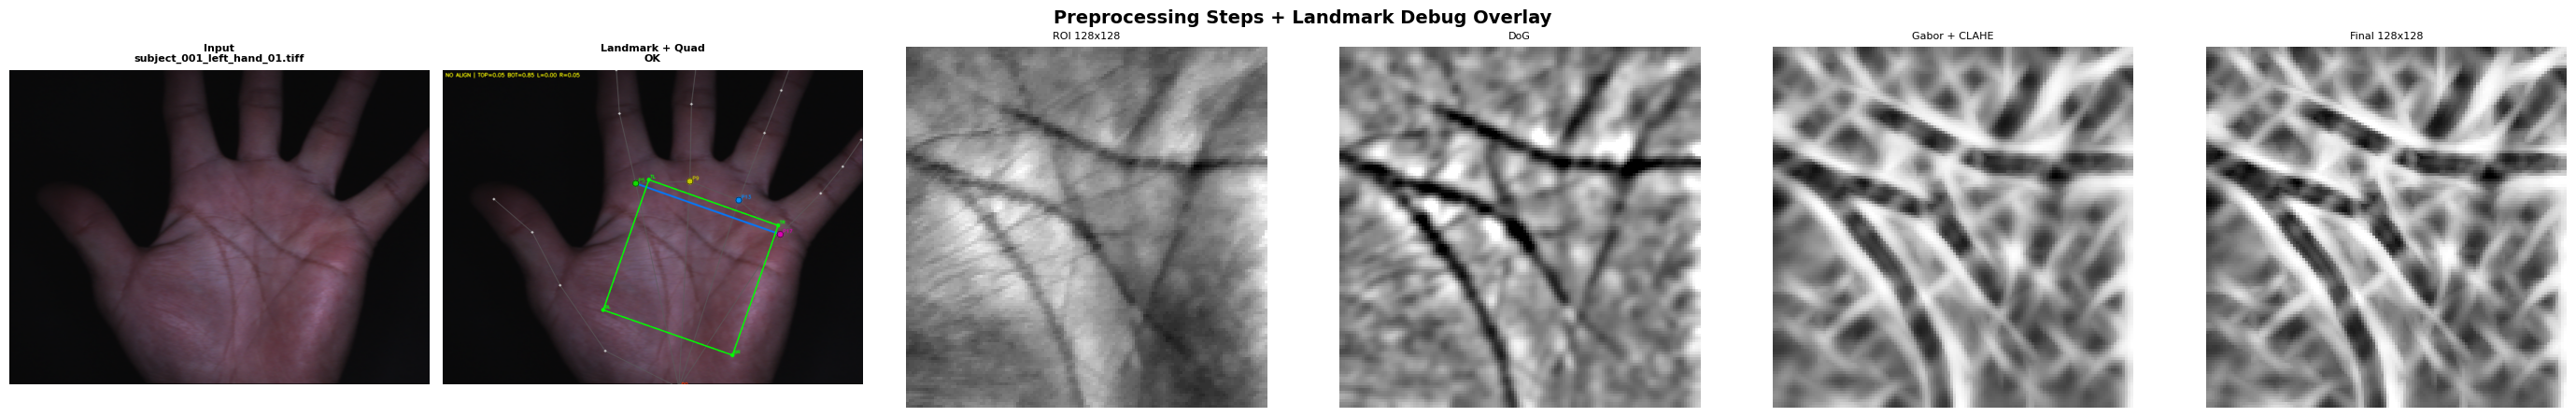

Menampilkan 1 gambar dari total 3000 gambar
Tersimpan: debug_overlay_output.png


In [63]:
def normalize_illumination(img_gray, sigma_small=1.0, sigma_large=5.0):
    img_f = img_gray.astype(np.float32)

    # Tidak ada denoise — langsung DoG seperti training asli
    g_small = cv2.GaussianBlur(img_f, (0, 0), sigmaX=sigma_small)
    g_large = cv2.GaussianBlur(img_f, (0, 0), sigmaX=sigma_large)

    dog = g_small - g_large
    dog = dog - dog.mean()
    lo, hi = np.percentile(dog, [1, 99])
    dog_clipped = np.clip(dog, lo, hi)
    return cv2.normalize(dog_clipped, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)


def enhance_gabor(img_gray, use_dog=True):
    if use_dog:
        img_gray = normalize_illumination(img_gray)

    responses = []
    scales = [
        {"sigma": 3.5, "lambda": 12.0},  # tetap — principal lines
        {"sigma": 2.0, "lambda": 7.0},  # dari 1.2/4.0 — sedikit lebih besar
    ]
    for scale in scales:
        for theta in Config.GABOR_THETAS:
            kernel = cv2.getGaborKernel(
                ksize=(Config.GABOR_KSIZE, Config.GABOR_KSIZE),
                sigma=scale["sigma"],
                theta=theta,
                lambd=scale["lambda"],
                gamma=Config.GABOR_GAMMA,
                psi=0,
                ktype=cv2.CV_32F,
            )
            resp = cv2.filter2D(img_gray.astype(np.float32), cv2.CV_32F, kernel)
            responses.append(np.abs(resp))

    gabor_max = np.max(responses, axis=0)
    gabor_mean = np.mean(responses, axis=0)
    combined = 0.4 * gabor_max + 0.6 * gabor_mean
    combined = cv2.normalize(combined, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)


    # hapus baris medianBlur

    clahe = cv2.createCLAHE(clipLimit=Config.CLAHE_CLIP, tileGridSize=Config.CLAHE_TILE)
    return clahe.apply(combined)


def sharpen_and_resize(img_gray):
    gaussian = cv2.GaussianBlur(img_gray, (5, 5), 2.0)
    sharpened = cv2.addWeighted(img_gray, 1.5, gaussian, -0.5, 0)  # dari 1.8/-0.8
    return cv2.resize(
        sharpened, (Config.IMAGE_SIZE, Config.IMAGE_SIZE), interpolation=cv2.INTER_CUBIC
    )


# ── Visualisasi preprocessing + DEBUG OVERLAY ───────────────────────────────

exts = (".png", ".jpg", ".jpeg", ".bmp", ".tiff", ".tif")

samples = sorted(
    [f for f in os.listdir(Config.DATASET_PATH) if f.lower().endswith(exts)]
)

# =====================================================
# UBAH ANGKA INI SAJA
# 1  = tampil 1 gambar
# 3  = tampil 3 gambar
# 10 = tampil 10 gambar
# =====================================================
num_samples = min(1, len(samples))

fig, axes = plt.subplots(num_samples, 6, figsize=(28, 4.5 * num_samples))

# Jika hanya 1 sampel, ubah menjadi array 2D
if num_samples == 1:
    axes = axes.reshape(1, -1)

fig.suptitle(
    "Preprocessing Steps + Landmark Debug Overlay", fontsize=14, fontweight="bold"
)

for row in range(num_samples):

    img_path = os.path.join(Config.DATASET_PATH, samples[row])

    img_s = cv2.imread(img_path)

    # =================================================
    # PIPELINE
    # =================================================
    roi_gray, dbg = detect_palm_opencv(img_s, debug=True)

    dog_s = normalize_illumination(roi_gray)

    gabor_dog_s = enhance_gabor(dog_s, use_dog=False)

    roi_for_hog = sharpen_and_resize(gabor_dog_s)

    status = "FALLBACK" if dbg["fallback"] else "OK"

    # =================================================
    # KOLOM 1 : INPUT
    # =================================================
    axes[row, 0].imshow(cv2.cvtColor(img_s, cv2.COLOR_BGR2RGB))

    axes[row, 0].set_title(f"Input\n{samples[row]}", fontsize=8, fontweight="bold")

    axes[row, 0].axis("off")

    # =================================================
    # KOLOM 2 : LANDMARK + QUAD
    # =================================================
    overlay = dbg.get("debug_overlay", img_s)

    axes[row, 1].imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))

    axes[row, 1].set_title(
        f"Landmark + Quad\n{status}",
        fontsize=8,
        fontweight="bold",
        color="red" if dbg["fallback"] else "black",
    )

    axes[row, 1].axis("off")

    # =================================================
    # KOLOM 3 : ROI
    # =================================================
    axes[row, 2].imshow(roi_gray, cmap="gray")

    axes[row, 2].set_title(f"ROI {roi_gray.shape[1]}x{roi_gray.shape[0]}", fontsize=8)

    axes[row, 2].axis("off")

    # =================================================
    # KOLOM 4 : DoG
    # =================================================
    axes[row, 3].imshow(dog_s, cmap="gray")

    axes[row, 3].set_title("DoG", fontsize=8)

    axes[row, 3].axis("off")

    # =================================================
    # KOLOM 5 : GABOR + CLAHE
    # =================================================
    axes[row, 4].imshow(gabor_dog_s, cmap="gray")

    axes[row, 4].set_title("Gabor + CLAHE", fontsize=8)

    axes[row, 4].axis("off")

    # =================================================
    # KOLOM 6 : FINAL
    # =================================================
    axes[row, 5].imshow(roi_for_hog, cmap="gray")

    axes[row, 5].set_title(f"Final {Config.IMAGE_SIZE}x{Config.IMAGE_SIZE}", fontsize=8)

    axes[row, 5].axis("off")

plt.tight_layout()

plt.savefig("debug_overlay_output.png", dpi=120, bbox_inches="tight")

plt.show()

print(f"Menampilkan {num_samples} gambar dari total {len(samples)} gambar")

print("Tersimpan: debug_overlay_output.png")

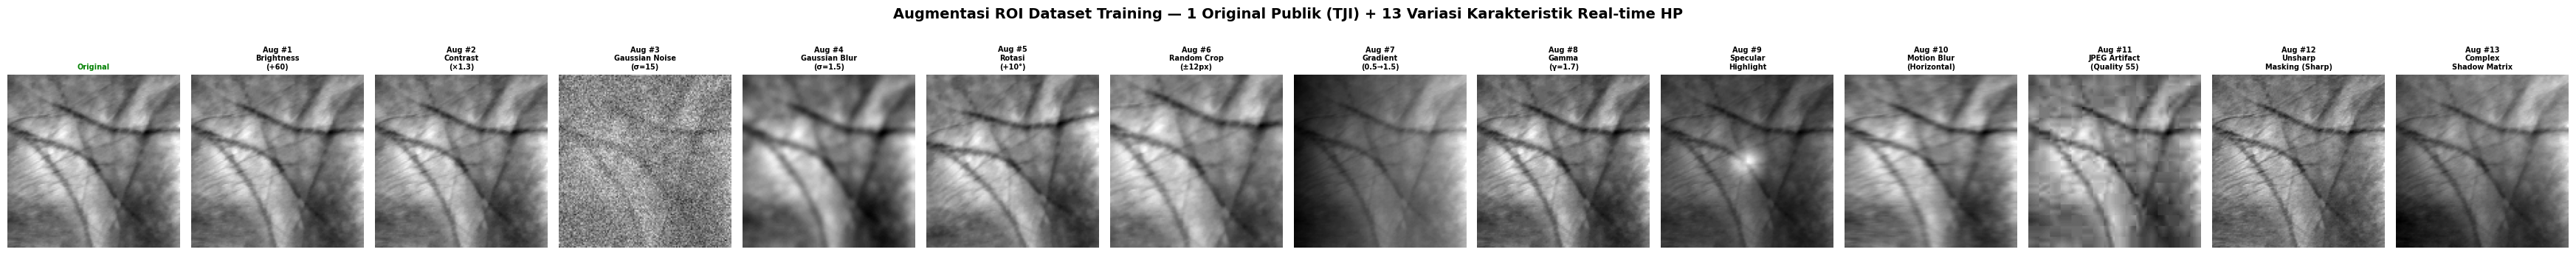

✓ Visualisasi 13 augmentasi data latih selesai dijalankan!
  File laporan aman tersimpan di: results/augmentasi_laporan.png


In [64]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

# =========================================================================
# 1. DEFINISI FUNGSI AUGMENTASI UPGRADE (12 Variasi Gangguan Kamera HP)
# =========================================================================
def augment_roi(roi_gray, n_aug=3):
    """
    PREMIUM UPGRADE: Augmentasi ROI Palmprint khusus untuk menjembatani
    Domain Gap antara Dataset Publik (TJI) dengan Kamera HP (Real-time Flutter).
    """
    h, w = roi_gray.shape[:2]
    results = []

    for _ in range(n_aug):
        aug = roi_gray.copy().astype(np.float32)

        # 1. Brightness shift ±60
        if np.random.random() < 0.5:
            aug = np.clip(aug + np.random.uniform(-60, 60), 0, 255)

        # 2. Contrast scaling (Simulasi HDR kamera HP)
        if np.random.random() < 0.5:
            aug = np.clip(aug * np.random.uniform(0.7, 1.3), 0, 255)

        # 3. Gaussian noise (Simulasi ISO tinggi / low-light HP)
        if np.random.random() < 0.5:
            noise = np.random.normal(0, np.random.uniform(5, 15), aug.shape)
            aug = np.clip(aug + noise, 0, 255)

        # 4. Gaussian blur ringan
        if np.random.random() < 0.4:
            aug = cv2.GaussianBlur(aug, (0, 0), np.random.uniform(0.5, 1.5))

        # 5. Rotasi kecil ±10°
        if np.random.random() < 0.6:
            angle = np.random.uniform(-10, 10)
            M = cv2.getRotationMatrix2D((w // 2, h // 2), angle, 1.0)
            aug = cv2.warpAffine(aug, M, (w, h), flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_REFLECT)

        # 6. Random crop + resize balik
        if np.random.random() < 0.5:
            margin = 15
            x1 = np.random.randint(0, margin)
            y1 = np.random.randint(0, margin)
            x2 = w - np.random.randint(0, margin)
            y2 = h - np.random.randint(0, margin)
            aug = cv2.resize(aug[y1:y2, x1:x2], (w, h), interpolation=cv2.INTER_LINEAR)

        # 7. Brightness gradient (Simulasi bayangan HP menutup sebagian telapak)
        if np.random.random() < 0.5:
            gradient = np.linspace(np.random.uniform(0.5, 0.9), np.random.uniform(1.1, 1.5), w).astype(np.float32)
            aug = np.clip(aug * gradient[np.newaxis, :], 0, 255)

        # 8. Gamma correction (Simulasi auto-exposure otomatis milik Android/iOS)
        if np.random.random() < 0.5:
            gamma = np.random.uniform(0.5, 1.8)
            aug_norm = np.clip(aug / 255.0, 1e-7, 1.0)
            aug = np.clip(255.0 * (aug_norm ** gamma), 0, 255)

        # 9. Specular highlight (Titik pantul kilatan lampu flash/ruangan)
        if np.random.random() < 0.4:
            cx = np.random.randint(20, w - 20)
            cy = np.random.randint(20, h - 20)
            radius = np.random.randint(10, 30)
            Y_grid, X_grid = np.ogrid[:h, :w]
            dist = np.sqrt((X_grid - cx)**2 + (Y_grid - cy)**2)
            mask = (dist <= radius).astype(np.float32)
            intensity = np.random.uniform(60, 110)
            falloff = np.clip(1 - dist / radius, 0, 1) ** 2
            aug = np.clip(aug + intensity * falloff * mask, 0, 255)

        # 10. Motion blur ringan (Efek tangan tremor saat menekan tombol capture)
        if np.random.random() < 0.3:
            ksize = np.random.choice([3, 5])
            angle = np.random.uniform(0, 180)
            kernel = np.zeros((ksize, ksize), dtype=np.float32)
            kernel[ksize // 2, :] = 1.0 / ksize
            M_rot = cv2.getRotationMatrix2D((float(ksize // 2), float(ksize // 2)), angle, 1)
            kernel = cv2.warpAffine(kernel, M_rot, (ksize, ksize))
            aug = cv2.filter2D(aug.astype(np.float32), -1, kernel)

        # 11. JPEG compression artifact (Khas gambar yang dikirim via HTTP POST)
        if np.random.random() < 0.4:
            quality = np.random.randint(55, 80)
            _, enc = cv2.imencode('.jpg', aug.astype(np.uint8), [cv2.IMWRITE_JPEG_QUALITY, quality])
            aug = cv2.imdecode(enc, cv2.IMREAD_GRAYSCALE).astype(np.float32)

        # 12. Unsharp Masking (Simulasi Ketajaman Sensor HP Modern)
        if np.random.random() < 0.4:
            blur_for_sharp = cv2.GaussianBlur(aug, (5, 5), 1.0)
            aug = np.clip(aug + np.random.uniform(0.5, 1.5) * (aug - blur_for_sharp), 0, 255)

        # 13. Complex Shadow Matrix (Simulasi Bayangan Jari/HP Diagonal)
        if np.random.random() < 0.4:
            Y_grid, X_grid = np.meshgrid(np.arange(h), np.arange(w), indexing='ij')
            shadow_pattern = (X_grid * np.random.uniform(-0.5, 0.5) + Y_grid * np.random.uniform(-0.5, 0.5))
            shadow_pattern = cv2.normalize(shadow_pattern, None, 0.6, 1.0, cv2.NORM_MINMAX)
            aug = np.clip(aug * shadow_pattern, 0, 255)

        results.append(aug.astype(np.uint8))

    return results


# =========================================================================
# 2. VISUALISASI DETERMINISTIK UNTUK LAPORAN BAB 3 / BAB 4
# =========================================================================
os.makedirs('results', exist_ok=True)

try:
    # Menggunakan fungsi bawaan dari file training utama kamu untuk ekstrak sampel pertama
    # Pastikan 'img_s' adalah variabel gambar mentah orisinal yang valid dari dataset publik
    roi_s, _ = detect_palm_opencv(img_s) 
    h, w = roi_s.shape[:2]

    # Fungsi pembantu untuk menghasilkan efek tunggal yang stabil (bukan acak) khusus visualisasi laporan
    def apply_single_deterministic(roi, aug_type):
        aug = roi.copy().astype(np.float32)
        if aug_type == 1:    # Brightness shift
            aug = np.clip(aug + 60, 0, 255)
        elif aug_type == 2:  # Contrast scaling
            aug = np.clip(aug * 1.3, 0, 255)
        elif aug_type == 3:  # Gaussian noise
            noise = np.random.normal(0, 15, aug.shape)
            aug = np.clip(aug + noise, 0, 255)
        elif aug_type == 4:  # Gaussian blur
            aug = cv2.GaussianBlur(aug, (0, 0), 1.5)
        elif aug_type == 5:  # Rotasi
            M = cv2.getRotationMatrix2D((w//2, h//2), 10, 1.0)
            aug = cv2.warpAffine(aug, M, (w, h), flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_REFLECT)
        elif aug_type == 6:  # Random crop
            x1, y1, x2, y2 = 12, 12, w-12, h-12
            aug = cv2.resize(aug[y1:y2, x1:x2], (w, h), interpolation=cv2.INTER_LINEAR)
        elif aug_type == 7:  # Brightness gradient
            gradient = np.linspace(0.5, 1.5, w).astype(np.float32)
            aug = np.clip(aug * gradient[np.newaxis, :], 0, 255)
        elif aug_type == 8:  # Gamma correction
            aug_norm = np.clip(aug / 255.0, 1e-7, 1.0)
            aug = np.clip(255.0 * (aug_norm ** 1.7), 0, 255)
        elif aug_type == 9:  # Specular Highlight
            cx, cy, radius = w//2, h//2, 22
            Y_grid, X_grid = np.ogrid[:h, :w]
            dist = np.sqrt((X_grid - cx)**2 + (Y_grid - cy)**2)
            mask = (dist <= radius).astype(np.float32)
            falloff = np.clip(1 - dist / radius, 0, 1) ** 2
            aug = np.clip(aug + 90 * falloff * mask, 0, 255)
        elif aug_type == 10: # Motion Blur
            kernel = np.zeros((5, 5), dtype=np.float32)
            kernel[2, :] = 1.0 / 5
            aug = cv2.filter2D(aug, -1, kernel)
        elif aug_type == 11: # JPEG Artifact
            _, enc = cv2.imencode('.jpg', aug.astype(np.uint8), [cv2.IMWRITE_JPEG_QUALITY, 55])
            aug = cv2.imdecode(enc, cv2.IMREAD_GRAYSCALE)
        elif aug_type == 12: # Unsharp Masking
            blur_for_sharp = cv2.GaussianBlur(aug, (5, 5), 1.0)
            aug = np.clip(aug + 1.5 * (aug - blur_for_sharp), 0, 255)
        elif aug_type == 13: # Complex Shadow Matrix
            Y_grid, X_grid = np.meshgrid(np.arange(h), np.arange(w), indexing='ij')
            shadow_pattern = (X_grid * 0.3 + Y_grid * -0.3)
            shadow_pattern = cv2.normalize(shadow_pattern, None, 0.5, 1.0, cv2.NORM_MINMAX)
            aug = np.clip(aug * shadow_pattern, 0, 255)
            
        return aug.astype(np.uint8)

    labels = [
        'Original',
        'Aug #1\nBrightness\n(+60)',
        'Aug #2\nContrast\n(×1.3)',
        'Aug #3\nGaussian Noise\n(σ=15)',
        'Aug #4\nGaussian Blur\n(σ=1.5)',
        'Aug #5\nRotasi\n(+10°)',
        'Aug #6\nRandom Crop\n(±12px)',
        'Aug #7\nGradient\n(0.5→1.5)',
        'Aug #8\nGamma\n(γ=1.7)',
        'Aug #9\nSpecular\nHighlight',
        'Aug #10\nMotion Blur\n(Horizontal)',
        'Aug #11\nJPEG Artifact\n(Quality 55)',
        'Aug #12\nUnsharp\nMasking (Sharp)',
        'Aug #13\nComplex\nShadow Matrix'
    ]

    # Gabungkan gambar asli dengan 13 variasi augmentasi secara berurutan
    aug_images = [roi_s] + [apply_single_deterministic(roi_s, i) for i in range(1, 14)]

    # Plot diperlebar menjadi 1 baris, 14 kolom agar muat semua jenis augmentasi
    fig, axes = plt.subplots(1, 14, figsize=(35, 4))
    fig.suptitle("Augmentasi ROI Dataset Training — 1 Original Publik (TJI) + 13 Variasi Karakteristik Real-time HP", 
                 fontsize=14, fontweight="bold")

    for i, (img_aug, label) in enumerate(zip(aug_images, labels)):
        axes[i].imshow(img_aug, cmap='gray')
        color = 'green' if i == 0 else 'black'
        axes[i].set_title(label, fontweight='bold', color=color, fontsize=7)
        axes[i].axis('off')

    plt.tight_layout()
    plt.savefig('results/augmentasi_laporan.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✓ Visualisasi 13 augmentasi data latih selesai dijalankan!")
    print("  File laporan aman tersimpan di: results/augmentasi_laporan.png")

except NameError as e:
    print(f"Error: Variabel gambar atau fungsi deteksi belum siap. Detail: {e}")
    print("Pastikan cell pembacaan dataset utama ('img_s') dan fungsi 'detect_palm_opencv' sudah di-run terlebih dahulu sebelum cell ini.")

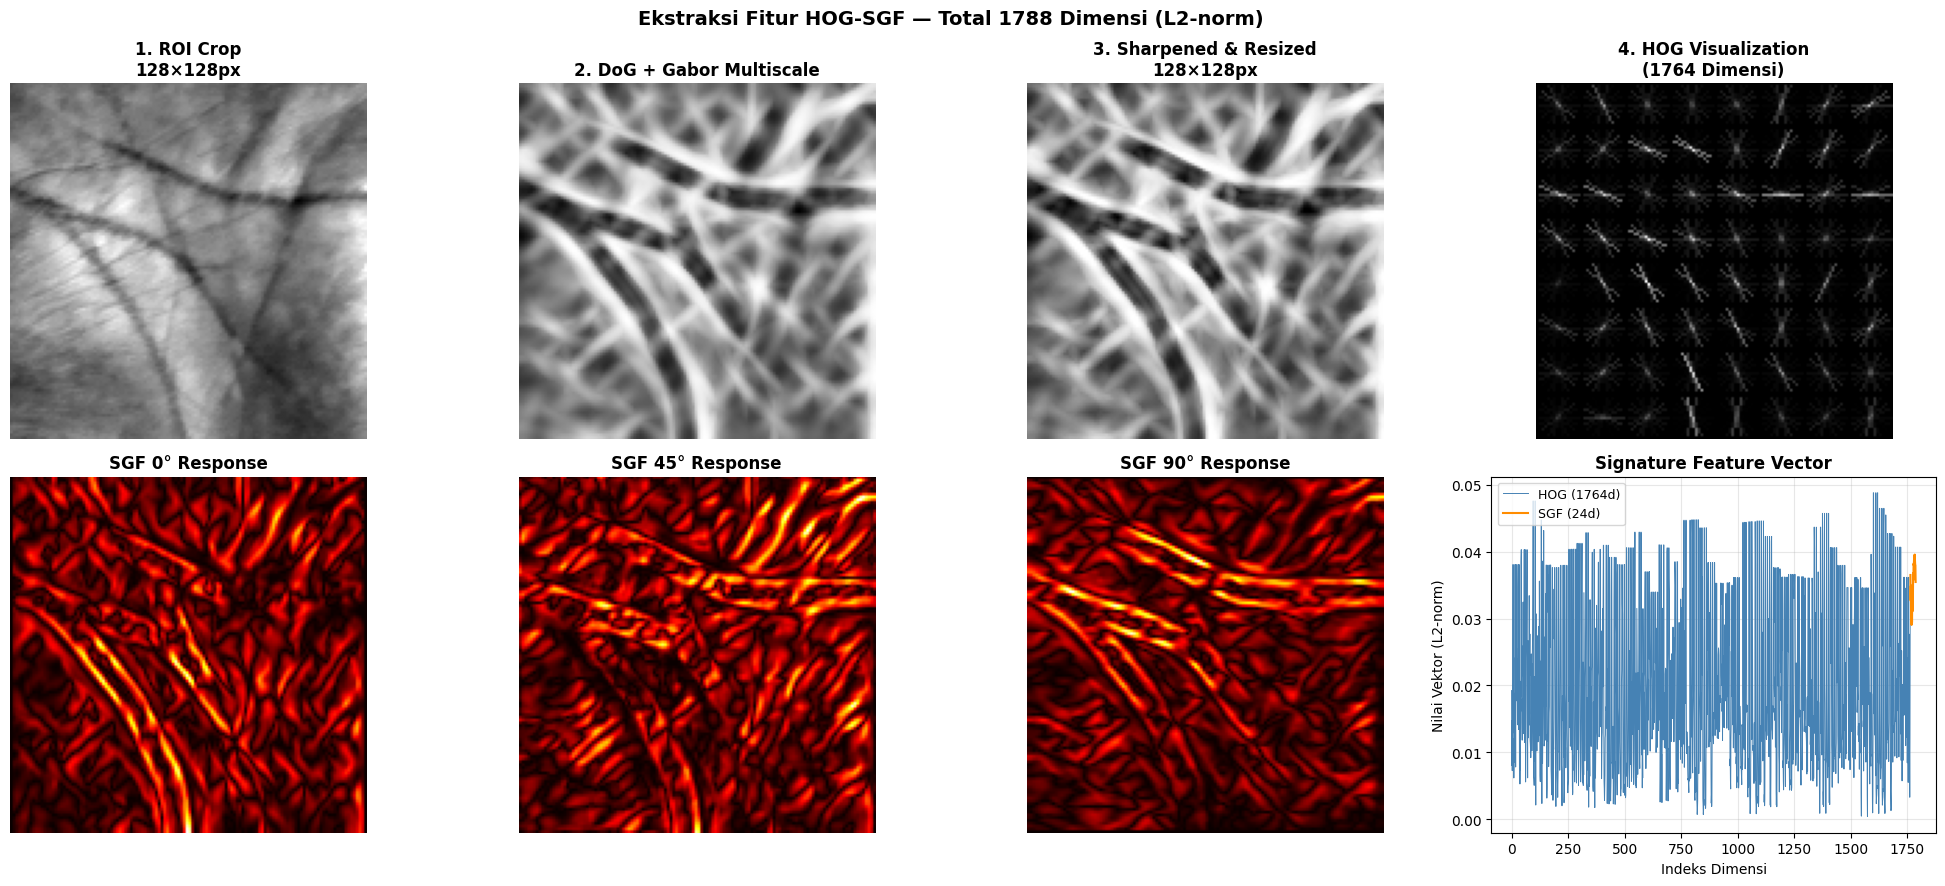

✓ Sukses! Dimensi Ekstraksi Fitur Baru: 1788 (1764d HOG + 24d SGF)


In [65]:
def extract_hog_sgf(img_gray, hog_orient=None, hog_pixels=None,
                    hog_cells=None, visualize=False):
    orient = hog_orient or Config.HOG_ORIENT
    pixels = hog_pixels or Config.HOG_PIXELS
    cells  = hog_cells  or Config.HOG_CELLS

    img_64 = cv2.resize(img_gray, (Config.IMAGE_SIZE, Config.IMAGE_SIZE))

    # ── 1. HOG ──
    if visualize:
        hog_feat, hog_img = hog(
            img_64, orientations=orient,
            pixels_per_cell=(pixels, pixels),
            cells_per_block=(cells, cells),
            block_norm='L2-Hys',        # ← diubah dari 'L2'
            visualize=True
        )
    else:
        hog_feat = hog(
            img_64, orientations=orient,
            pixels_per_cell=(pixels, pixels),
            cells_per_block=(cells, cells),
            block_norm='L2-Hys',        # ← diubah dari 'L2'
            visualize=False
        )
        hog_img = None

    # ── 2. SGF ──
    img_f = img_64.astype(np.float32)
    Ix    = cv2.Sobel(img_f, cv2.CV_32F, 1, 0, ksize=3)
    Iy    = cv2.Sobel(img_f, cv2.CV_32F, 0, 1, ksize=3)

    sgf_feats = []
    sgf_responses_vis = {}

    for theta in Config.SGF_ANGLES:
        FR     = np.cos(theta) * Ix + np.sin(theta) * Iy
        FR_abs = np.abs(FR)                              # ← tambahan
        sgf_feats.extend([np.mean(FR_abs), np.std(FR_abs)])  # ← pakai FR_abs

        theta_deg = int(np.degrees(theta))
        if visualize and theta_deg in [0, 45, 90]:
            sgf_responses_vis[theta_deg] = FR_abs.copy()    # ← simpan FR_abs

    sgf_feat = np.array(sgf_feats, dtype=np.float32)

    # ── 3. KOMBINASI & L2-NORMALIZATION ──
    hog_norm = hog_feat / np.maximum(np.linalg.norm(hog_feat), 1e-8)
    sgf_norm = sgf_feat / np.maximum(np.linalg.norm(sgf_feat), 1e-8)
    combined = np.concatenate([hog_norm * Config.HOG_SGF_WEIGHT,
                                sgf_norm * (1 - Config.HOG_SGF_WEIGHT)])
    total_norm = np.linalg.norm(combined)
    if total_norm > 0:
        combined = combined / total_norm

    if visualize:
        return combined, hog_img, img_64, sgf_responses_vis
    return combined
 
 
# ── REVISI VISUALISASI EKSTRAKSI FITUR PADA SAMPEL DATASET DATA LATIH ──
if 'roi_s' in locals() or 'roi_s' in globals():
    # 1. Gunakan pipeline fungsi baru yang sudah di-improve agar sinkron dengan rantai data latih
    dog_s = normalize_illumination(roi_s)   
    enh_s = enhance_gabor(dog_s, use_dog=False) # use_dog=False karena dog_s sudah dihitung manual diatas
    
    # KUNCI PERBAIKAN: Masukkan tahap Sharpening sebelum masuk ke ekstraksi descriptor fitur
    sharpened_s = sharpen_and_resize(enh_s)
    
    # Memanggil fungsi ekstraksi fitur (menggunakan citra sharpened_s hasil unsharp masking)
    feat_s, hog_img_s, img64_s, sgf_responses_s = extract_hog_sgf(sharpened_s, visualize=True)
 
    sgf_dim = len(Config.SGF_ANGLES) * 2
    hog_dim = len(feat_s) - sgf_dim
 
    fig, axes = plt.subplots(2, 4, figsize=(20, 9))
    fig.suptitle(f'Ekstraksi Fitur HOG-SGF — Total {len(feat_s)} Dimensi (L2-norm)', fontsize=14, fontweight='bold')
 
    # Row 0: Tahapan Citra Preprocessing & Descriptor
    axes[0, 0].imshow(roi_s, cmap='gray')
    axes[0, 0].set_title(f'1. ROI Crop\n{roi_s.shape[1]}×{roi_s.shape[0]}px', fontweight='bold')
    axes[0, 0].axis('off')
 
    axes[0, 1].imshow(enh_s, cmap='gray')
    axes[0, 1].set_title('2. DoG + Gabor Multiscale', fontweight='bold')
    axes[0, 1].axis('off')
 
    # REVISI JUDUL KOTAK: Menampilkan citra hasil penajaman yang siap diekstrak oleh HOG
    axes[0, 2].imshow(img64_s, cmap='gray')
    axes[0, 2].set_title(f'3. Sharpened & Resized\n{Config.IMAGE_SIZE}×{Config.IMAGE_SIZE}px', fontweight='bold')
    axes[0, 2].axis('off')
 
    axes[0, 3].imshow(hog_img_s, cmap='gray')
    axes[0, 3].set_title(f'4. HOG Visualization\n({hog_dim} Dimensi)', fontweight='bold')
    axes[0, 3].axis('off')
 
    # Row 1: Menampilkan Respon SGF Tanpa Perlu Kalkulasi Ulang (Mengambil dari Dictionary)
    vis_mapping = [(0, 'SGF 0° Response'), (45, 'SGF 45° Response'), (90, 'SGF 90° Response')]
    
    for col, (deg, title) in enumerate(vis_mapping):
        if deg in sgf_responses_s:
            FR_matrix = sgf_responses_s[deg]
            FR_n = cv2.normalize(np.abs(FR_matrix), None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
            axes[1, col].imshow(FR_n, cmap='hot')
            axes[1, col].set_title(title, fontweight='bold')
        else:
            axes[1, col].text(0.5, 0.5, f'{deg}° Not In Config', ha='center', va='center', fontweight='bold')
        axes[1, col].axis('off')
 
    # Plot gabungan representasi nilai array fitur
    axes[1, 3].plot(feat_s[:hog_dim], lw=0.7, color='steelblue', label=f'HOG ({hog_dim}d)')
    axes[1, 3].plot(range(hog_dim, hog_dim + sgf_dim), feat_s[hog_dim:], lw=1.5, color='darkorange', label=f'SGF ({sgf_dim}d)')
    axes[1, 3].set_title(f'Signature Feature Vector', fontweight='bold')
    axes[1, 3].legend(fontsize=9)
    axes[1, 3].grid(True, alpha=0.3)
    axes[1, 3].set_xlabel('Indeks Dimensi')
    axes[1, 3].set_ylabel('Nilai Vektor (L2-norm)')
 
    plt.tight_layout()
    plt.show()
    print(f'✓ Sukses! Dimensi Ekstraksi Fitur Baru: {len(feat_s)} ({hog_dim}d HOG + {sgf_dim}d SGF)')